## 2D spectrum

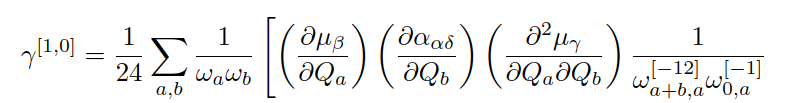

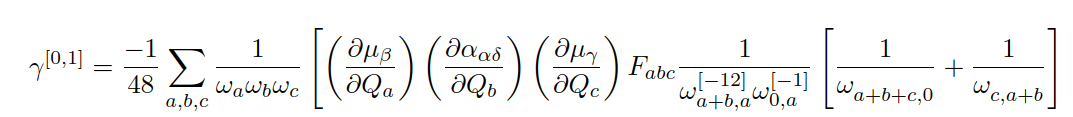

In [21]:
# w1, w1-w2
import math
import numpy as np
import matplotlib.pyplot as plt

deriv_mu = np.array([
    np.array([0.1, 0.1, 0.1]), 
    np.array([0.1, 0.1, 0.1]), 
    np.array([0.1, 0.1, 0.1])
])

deriv_alpha = np.array([
    np.array([0.1, 0.1, 0.1]), 
    np.array([0.1, 0.1, 0.1]), 
    np.array([0.1, 0.1, 0.1])
])

w = {0: 4, 1: 6, 2: 11}
combs = {}

a, b, c = 0, 1, 2

# Gamma = np.array([
#     np.array([0.001, 0.001, 0.001]),
#     np.array([0.001, 0.001, 0.001]),
#     np.array([0.001, 0.001, 0.001])
# ])

Gamma = 0.001


# electrical anharmonicity
# @np.vectorize
def el_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, w):
    """
    a, b, c - normal modes indices as strings
    w - dictionary of normal modes freqs, including some combination bands and overtones
        k:v '(str index or str combination)': freq
    w1 - range of w1 axis values
    w2 - range of w2 axis values
    w1mw2 = w1-w2
    deriv_mu, deriv_alpha - 2D arrays
    """
    
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)))
    
    for a in range(3):
        for b in range(3):
            # print(a, b)
            firstfrac = 1/ w[a] / w[b]
            derivs1 = deriv_mu[a, a] * deriv_alpha[b, b] * deriv_mu[a, b]
            
            resonance1_1 = (w[a] + w[b] - 0.4) - w[a] - w1mw2 - Gamma
            resonance2_1 = w_0 - w[a] + w1 - Gamma
            term1 = derivs1 / resonance1_1 / resonance2_1
            
            totalres += firstfrac * (term1)
    # print(totalres)
    return totalres/24


def mech_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, F, w):
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)))
    
    for a in range(3):
        for b in range(3):
            firstfrac = 1 / w[a] / w[b] / w[c]
            
            fracs = 1 / ((w[a] + w[b] + w[c] - 0.4) - w_0) + 1 / (w[c] - (w[a] + w[b] - 0.4))
            derivs1 = deriv_mu[a, a] * deriv_alpha[b, b] * deriv_mu[c, c] 
            
            resonance1_1 = (w[a] + w[b] - 0.4) - w[a] - w1mw2 - Gamma 
            resonance2_1 = w_0 - w[a] - Gamma
            
            term1 = derivs1 * fracs * F[a, b, c] / resonance1_1 / resonance2_1
            
            totalres += firstfrac * (term1)
    
    return -totalres/48

# w1 = np.array([4, 8, 9])
# w2 = np.array([2, 6, 11])
# xx, yy = np.meshgrid(w1, w1+w2)

# z = (el_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, w) + mech_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, w))**2
# np.set_printoptions(suppress=True)
# print(z)

import matplotlib.pyplot as plt
   
def spectrum(w1, w2, w, F, option1=False, prt=False):
    # print(w)
    if option1:
        X, Y = np.meshgrid(w1, w1-w2)
    else:
        X, Y = np.meshgrid(w1, w2)

    # print(X, Y)
    # compute the third dimension at each point on the grid
    Z = (el_anh(X, Y, deriv_mu, deriv_alpha, Gamma, w) + mech_anh(X, Y, deriv_mu, deriv_alpha, Gamma, F, w))**2 * 10**11
    # Z = el_anh(X, Y)**2
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None
        
    return X, Y, Z

# def spectrumPlot(X, Y, Z):
#     # plot the points with the third dimension as color
#     fig, ax = plt.subplots()
#     fig.set_size_inches(9, 7)
    
#     # print(len(X.flatten()), len(Y.flatten()), len(Z.flatten()))
#     sc = ax.scatter(X.flatten(), Y.flatten(), c=Z.flatten(), cmap='viridis', s=200)

#     ax.set_xlabel('w1', fontsize=18)

#     if option1:
#         ax.set_ylabel('w1-w2', fontsize=18)
#     else:
#         ax.set_ylabel('w2', fontsize=18)

#     plt.colorbar(sc)
#     plt.grid()

#     # set the tick frequency on x and y axis
#     ax.set_xticks(np.linspace(-2, 15, 18))
#     ax.set_yticks(np.linspace(-2, 15, 18))
#     ax.set_xlim(-1, 7)
#     ax.set_ylim(-1, 7)
#     for i in range(len(w1)):
#         for j in range(len(w2)):
#             ax.text(X[i, j]-0.2, Y[i, j]+0.3, 
#                     f'{Z[i, j]:.3f}',
#                     #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
#                     ha='right', va='bottom')
#     # plt.show()
#     return ax

In [4]:
w2 = np.array([ 2, 3, 5])
w1 = np.array([ 2, 3, 5])

w = {0: 1,
     1: 4, 
     2: 6}

F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 0.01

%matplotlib widget
# spectrum(w1, w2, w, F, option1=False, prt=True)
# spectrum(w1, w2, w, F, option1=True)

<ipython-input-26-454b79732dc1>:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


interactive(children=(FloatSlider(value=0.1, description='Fabc', max=6.0, min=0.1), FloatSlider(value=2.0, des…

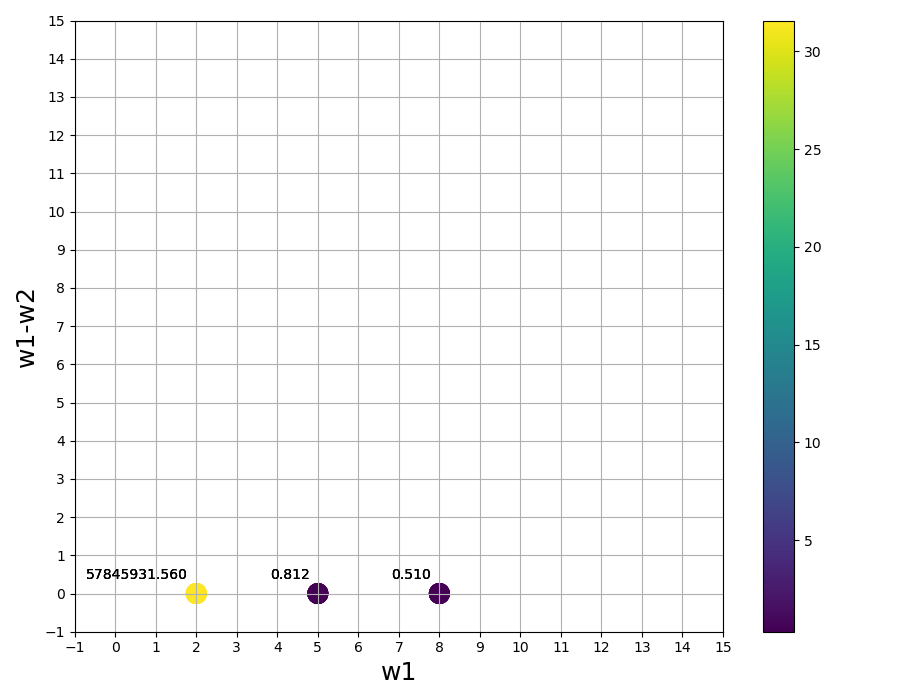

In [26]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt

w2 = np.array([ 2, 5, 8])
w1 = np.array([ 2, 5, 8])

w = {0: 1,
     1: 4, 
     2: 6}

F = np.zeros((len(w), len(w), len(w)))
# F[0, 1, 2] = 0.01

option1 = True

# x = np.linspace(0, 2 * np.pi)
# fig = plt.figure()
# ax = fig.add_subplot(1, 1, 1)
# line, = ax.plot(x, np.sin(x))

# plt.ion()

fig, ax = plt.subplots()
fig.set_size_inches(9, 7)

X, Y, Z = spectrum(w1, w2, w, F, option1=option1, prt=False)

# print(len(X.flatten()), len(Y.flatten()), len(Z.flatten()))
sc = ax.scatter(X.flatten(), Y.flatten(), c=Z.flatten(), cmap='viridis', s=200)

ax.set_xlabel('w1', fontsize=18)

if option1:
    ax.set_ylabel('w1-w2', fontsize=18)
else:
    ax.set_ylabel('w2', fontsize=18)

plt.colorbar(sc)
plt.grid()
fig.set_tight_layout(True)
# set the tick frequency on x and y axis
ax.set_xticks(np.linspace(-2, 15, 18))
ax.set_yticks(np.linspace(-2, 15, 18))
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 15)
for i in range(len(w1)):
    for j in range(len(w2)):
        ax.text(X[i, j]-0.2, Y[i, j]+0.3, 
                f'{Z[i, j]:.3f}',
                #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
                ha='right', va='bottom')

def update(Fabc, nu0, nu1):
    F[0, 1, 2] = Fabc
    w[0] = nu0
    w[1] = nu1
    
    Xp, Yp, Zp = spectrum(w1, w2, w, F, option1=option1, prt=False)

    ax.scatter(Xp.flatten(), Yp.flatten(), c=Zp.flatten(), cmap='viridis', s=200)
    # sc.set_offsets(np.c_[Xp,Yp])
    sc.set_array(Zp.flatten())

    for text in ax.texts:
        if text.get_text() != '':  # only remove ax.text objects
            text.remove()
            
    for i in range(len(w1)):
        for j in range(len(w2)):
            ax.text(Xp[i, j]-0.2, Yp[i, j]+0.3, 
                    f'{Zp[i, j]:.3f}',
                    #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
                    ha='right', va='bottom')
    fig.canvas.draw_idle()

    # print(Z)

Fabc_slider = FloatSlider(min=0.1, max=6, step=0.1, value=0.1)
nu0_slider = FloatSlider(min=1, max=5, step=0.5, value=2)
nu1_slider = FloatSlider(min=4, max=9, step=0.5, value=6)

interact(update, Fabc=Fabc_slider, nu0=nu0_slider, nu1=nu1_slider)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# generate some initial data
x = np.random.rand(10)
y = np.random.rand(10)
colors = np.random.rand(10)

# create a scatter plot of the data
fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=colors)

# define a function to update the data
def update_data():
    new_x = np.random.rand(10)
    new_y = np.random.rand(10)
    new_colors = np.random.rand(10)
    sc.set_offsets(np.c_[new_x, new_y])
    sc.set_array(new_colors)
    fig.canvas.draw()

# connect the function to a button click event
button_ax = fig.add_axes([0.8, 0.1, 0.1, 0.05])
button = plt.Button(button_ax, 'Update')
button.on_clicked(lambda event: update_data())

# show the plot
plt.show()
